<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [4]:
# Step 1: Download the dataset
# https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("survey_data.csv")

# Display the first few rows to understand the structure of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [84]:
df['LanguageHaveWorkedWith'].unique()

array([nan,
       'Bash/Shell (all shells);Go;HTML/CSS;Java;JavaScript;Python;TypeScript',
       'C#', ...,
       'Bash/Shell (all shells);C;C#;C++;Delphi;Groovy;HTML/CSS;Java;JavaScript;Objective-C;PowerShell;Python;SQL;Swift;TypeScript',
       'C;C++;Go;Lua;Objective-C;Python;Rust;SQL',
       'C;HTML/CSS;Java;JavaScript;PHP;Python;TypeScript'],
      shape=(23865,), dtype=object)

### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



In [5]:
## Write your code here
df_comp = df['ConvertedCompYearly'].dropna()

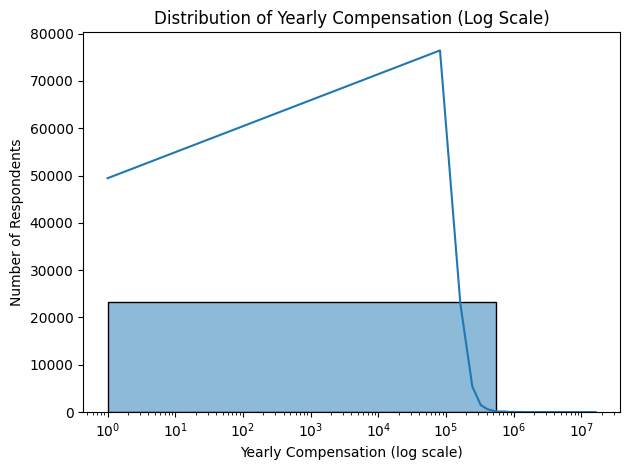

In [12]:
sns.histplot(
    data=df_comp,
    bins=30,
    kde=True
)

plt.xscale('log')
plt.title('Distribution of Yearly Compensation (Log Scale)')
plt.xlabel('Yearly Compensation (log scale)')
plt.ylabel('Number of Respondents')
plt.tight_layout()

The histogram of ConvertedCompYearly shows a strongly right-skewed distribution. Most respondents earn relatively low to mid-range annual compensation, while a small number of individuals earn exceptionally high salaries, creating a long right tail. This indicates significant income inequality within the respondent population, which is common in global tech surveys due to differences in roles, experience levels, countries, and seniority.

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



In [13]:
## Write your code here
df['Age'].unique()

array(['Under 18 years old', '35-44 years old', '45-54 years old',
       '18-24 years old', '25-34 years old', '55-64 years old',
       'Prefer not to say', '65 years or older'], dtype=object)

In [14]:
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

df_age = df[['Age']].dropna()
df_age['Age_num'] = df_age['Age'].map(age_map)
df_age = df_age.dropna()

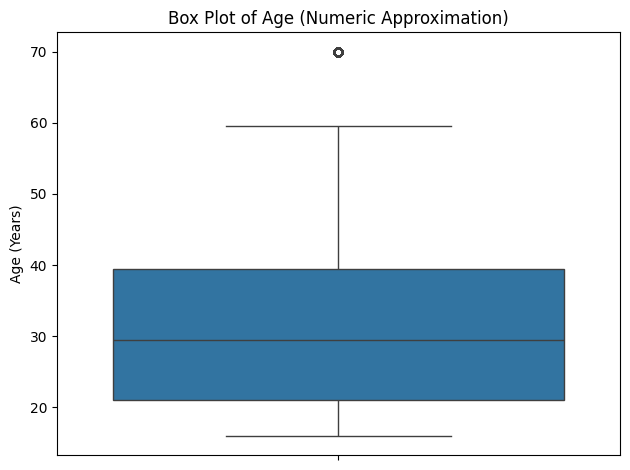

In [15]:
sns.boxplot(y=df_age['Age_num'])
plt.title('Box Plot of Age (Numeric Approximation)')
plt.ylabel('Age (Years)')
plt.tight_layout()

The box plot summarizes the central tendency and spread of respondents’ ages. The median lies at around 30 years, with most respondents clustered between approximately 25 and 40 years old. Any points beyond the whiskers indicate age groups with relatively fewer respondents (younger than 18 or older than 65).

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



In [23]:
## Write your code here
df_age_comp = df[['ConvertedCompYearly', 'Age']].dropna()

In [24]:
df_age_comp['Age_num'] = df_age_comp['Age'].map(age_map)

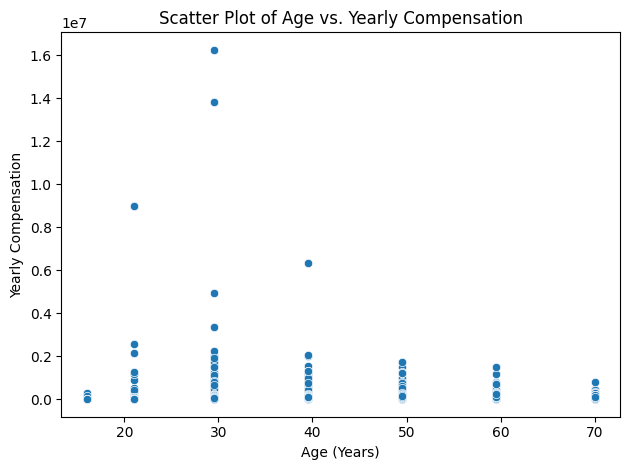

In [28]:
sns.scatterplot(
    x='Age_num',
    y='ConvertedCompYearly',
    data=df_age_comp
)
plt.title('Scatter Plot of Age vs. Yearly Compensation')
plt.xlabel('Age (Years)')
plt.ylabel('Yearly Compensation')
plt.tight_layout()

The scatter plot of Age versus ConvertedCompYearly shows a general upward trend in compensation with age, especially from early career (around 20–30 years) to mid-career (35–50 years). Most respondents cluster in the 25–45 age range, reflecting the largest segment of the workforce.

There is a wide spread in compensation for each age group, indicating that factors other than age such as role, experience, country, and employment type, also strongly influence salaries.

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


In [30]:
## Write your code here
df_comp_sat = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age']].dropna()
df_comp_sat['Age_num'] = df_comp_sat['Age'].map(age_map)

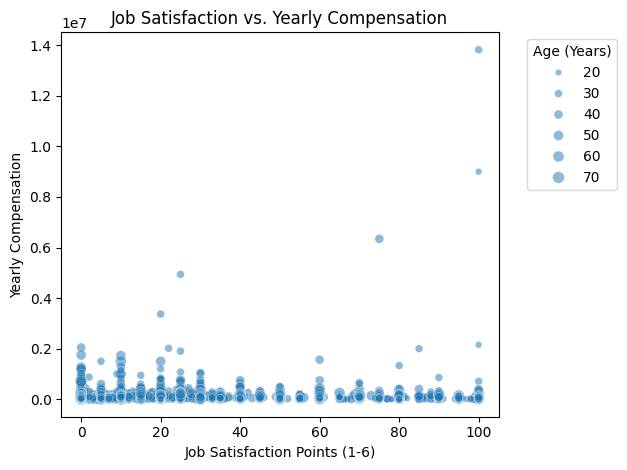

In [34]:
sns.scatterplot(
    x='JobSatPoints_6',
    y='ConvertedCompYearly',
    size='Age_num',
    data=df_comp_sat,
    alpha=0.5
)
plt.title('Job Satisfaction vs. Yearly Compensation')
plt.xlabel('Job Satisfaction Points (1-6)')
plt.ylabel('Yearly Compensation')
plt.legend(title='Age (Years)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

The bubble plot shows no strong linear correlation between job satisfaction and yearly compensation, suggesting that higher pay does not necessarily correspond to higher satisfaction. Most respondents cluster in the lower-to-mid compensation range regardless of satisfaction level.

The bubble sizes indicate that age varies across all compensation and satisfaction levels, with older respondents generally earning higher salaries but not always reporting higher satisfaction. The plot highlights the complex relationship among age, compensation, and satisfaction.

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



In [35]:
## Write your code here
df['MainBranch'].unique()

array(['I am a developer by profession', 'I am learning to code',
       'I code primarily as a hobby',
       'I am not primarily a developer, but I write code sometimes as part of my work/studies',
       'I used to be a developer by profession, but no longer am'],
      dtype=object)

In [36]:
df_roles = df['MainBranch'].dropna()
role_counts = df_roles.value_counts()

Text(0, 0.5, 'Main Branch')

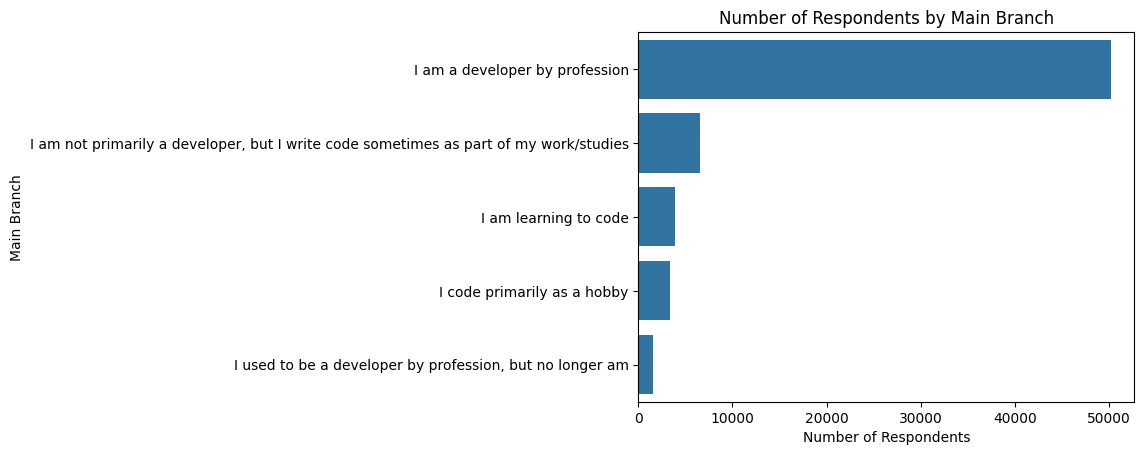

In [43]:
sns.barplot(
    x=role_counts.values,
    y=role_counts.index
)
plt.title('Number of Respondents by Main Branch')
plt.xlabel('Number of Respondents')
plt.ylabel('Main Branch')

The horizontal bar chart shows the distribution of respondents by their primary role (MainBranch):

- The majority of respondents are professional developers, indicating that the survey predominantly reflects the experiences of people actively working in software development.
- A smaller but notable portion of respondents are learning to code, suggesting interest from those entering the field.
- Fewer respondents code as a hobby or occasionally for work/study, and very few are former developers, showing that the dataset is heavily weighted toward current professionals.

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



In [45]:
## Write your code here
df['LanguageWantToWorkWith'].unique()

array([nan,
       'Bash/Shell (all shells);Go;HTML/CSS;Java;JavaScript;Kotlin;Python;TypeScript',
       'C#', ...,
       'Bash/Shell (all shells);C;C++;Elixir;Erlang;Go;HTML/CSS;Java;JavaScript;Kotlin;Lua;PowerShell;Python;Rust;Solidity;SQL;TypeScript;VBA;Visual Basic (.Net);Zig',
       'Bash/Shell (all shells);C;C++;Python;Ruby;SQL',
       'Bash/Shell (all shells);C#;Go;HTML/CSS;Java;JavaScript;Kotlin;Objective-C;Python;Rust;SQL;Swift;TypeScript'],
      shape=(22770,), dtype=object)

In [85]:
df_lang_want = df['LanguageWantToWorkWith'].dropna()
df_lang_want = df_lang_want.str.split(';').explode()
df_lang_want = df_lang_want.str.strip()

In [89]:
top5_lang_want = df_lang_want.value_counts().head(5)

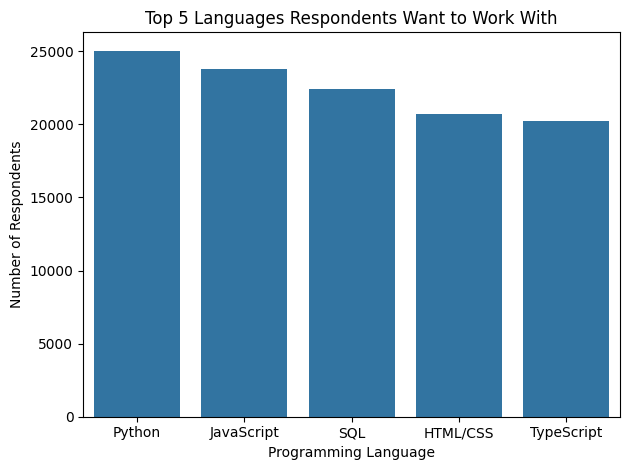

In [90]:
sns.barplot(
    x=top5_lang_want.index,
    y=top5_lang_want.values
)
plt.title('Top 5 Languages Respondents Want to Work With')
plt.xlabel('Programming Language')
plt.ylabel('Number of Respondents')
plt.tight_layout()

The bar chart shows the top 5 programming languages respondents want to work with, highlighting clear preferences for modern, widely adopted technologies.

- Python and JavaScript typically rank at the top, reflecting their versatility, strong job demand, and broad use across domains such as web development, data science, and automation.

- TypeScript and HTML/CSS appear prominently, indicating growing interest in scalable web applications and data-driven systems.

Overall, the distribution indicates that respondents are primarily interested in languages with strong ecosystem support, high employability, and relevance to current industry trends, reinforcing the market demand for full-stack, data-oriented, and scalable software skills.

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


In [59]:
## Write your code here
df_sat_age = df[['JobSatPoints_6', 'JobSatPoints_7', 'Age']].dropna()

median_sat_age = (
    df_sat_age
    .groupby(['Age'])[['JobSatPoints_6', 'JobSatPoints_7']]
    .median()
)

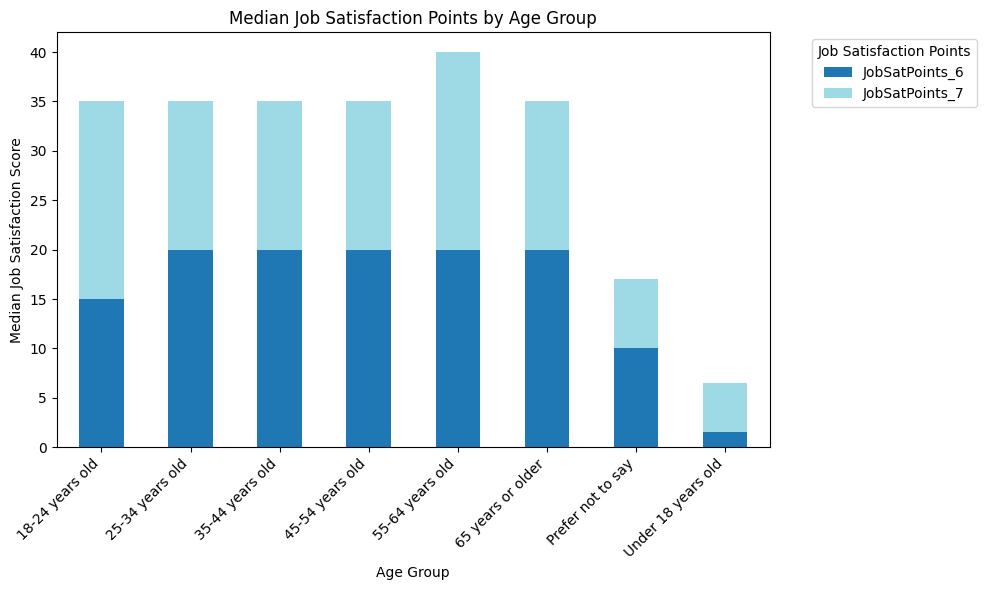

In [64]:
median_sat_age.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab20'
)

plt.title('Median Job Satisfaction Points by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Job Satisfaction Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Job Satisfaction Points', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

- Each bar represents an age group

- The stacked segments show how JobSatPoints_6 and JobSatPoints_7 jointly contribute to overall satisfaction

- You can quickly compare:

    - Which age groups report higher overall satisfaction

    - Whether satisfaction increases, decreases, or stabilizes with age

    - Differences between the two satisfaction dimensions across age groups

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



In [65]:
## Write your code here
df['DatabaseHaveWorkedWith'].unique()

array([nan, 'Dynamodb;MongoDB;PostgreSQL', 'Firebase Realtime Database',
       ..., 'MySQL;Presto;Redis;TiDB',
       'Dynamodb;Elasticsearch;IBM DB2;MariaDB;MySQL;PostgreSQL',
       'Couch DB;H2;Microsoft SQL Server;MySQL;Oracle;PostgreSQL;SQLite'],
      shape=(9051,), dtype=object)

In [66]:
df_db_worked = df['DatabaseHaveWorkedWith'].dropna()
df_db_worked = df_db_worked.str.split(';').explode()
df_db_worked = df_db_worked.str.strip()

In [67]:
top5_db_worked = df_db_worked.value_counts().head(5)

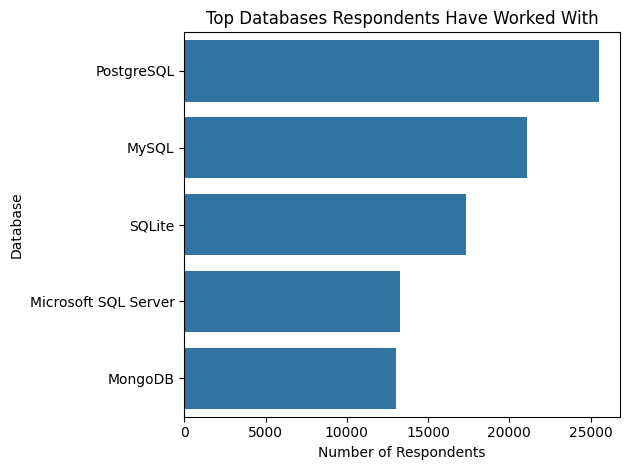

In [70]:
sns.barplot(
    x=top5_db_worked,
    y=top5_db_worked.index
)
plt.title('Top Databases Respondents Have Worked With')
plt.xlabel('Number of Respondents')
plt.ylabel('Database')
plt.tight_layout()

- PostgreSQL, MySQL, and SQLite typically dominate, reflecting their widespread use in web, backend, and data-driven applications.

- The popularity of cloud-friendly and open-source databases suggests strong adoption in modern development environments.

- The distribution indicates that respondents favor scalable, well-supported databases with strong community and industry backing.

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



In [73]:
## Write your code here
df_comp_age = df[['ConvertedCompYearly', 'Age']].dropna()

median_comp_age = (
    df_comp_age
    .groupby('Age', as_index=False)['ConvertedCompYearly']
    .median()
)

In [74]:
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]
median_comp_age['Age'] = pd.Categorical(
    median_comp_age['Age'],
    categories=age_order,
    ordered=True
)
median_comp_age = median_comp_age.sort_values('Age')

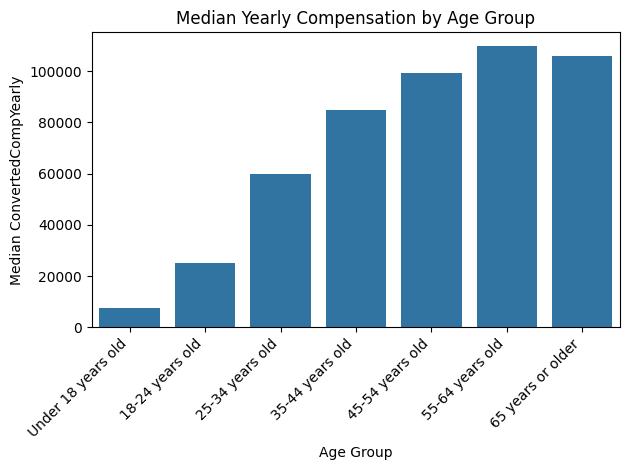

In [75]:
sns.barplot(
    data=median_comp_age,
    x='Age',
    y='ConvertedCompYearly'
)

plt.title('Median Yearly Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median ConvertedCompYearly')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

- Median compensation generally increases with age, peaking in typically 35–64 years.

- Younger respondents (under 25) show lower median compensation, reflecting early-career roles.

- Compensation may plateau or slightly decline in older age groups, possibly due to career transitions, part-time work, or retirement.

- Overall, the chart highlights a strong relationship between experience (age) and earning potential.

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



In [76]:
## Write your code here
df['Country'].unique()

array(['United States of America',
       'United Kingdom of Great Britain and Northern Ireland', 'Canada',
       'Norway', 'Uzbekistan', 'Serbia', 'Poland', 'Philippines',
       'Bulgaria', 'Switzerland', 'India', 'Germany', 'Ireland', 'Italy',
       'Ukraine', 'Australia', 'Brazil', 'Japan', 'Austria',
       'Iran, Islamic Republic of...', 'France', 'Saudi Arabia',
       'Romania', 'Turkey', 'Nepal', 'Algeria', 'Sweden', 'Netherlands',
       'Croatia', 'Pakistan', 'Czech Republic',
       'Republic of North Macedonia', 'Finland', 'Slovakia',
       'Russian Federation', 'Greece', 'Israel', 'Belgium', 'Mexico',
       'United Republic of Tanzania', 'Hungary', 'Argentina', 'Portugal',
       'Sri Lanka', 'Latvia', 'China', 'Singapore', 'Lebanon', 'Spain',
       'South Africa', 'Lithuania', 'Viet Nam', 'Dominican Republic',
       'Indonesia', 'Kosovo', 'Morocco', 'Taiwan', 'Georgia',
       'San Marino', 'Tunisia', 'Bangladesh', 'Nigeria', 'Liechtenstein',
       'Denmark', 'Ecu

In [77]:
df_country = df['Country'].dropna()
country_counts = df_country.value_counts().head(10)

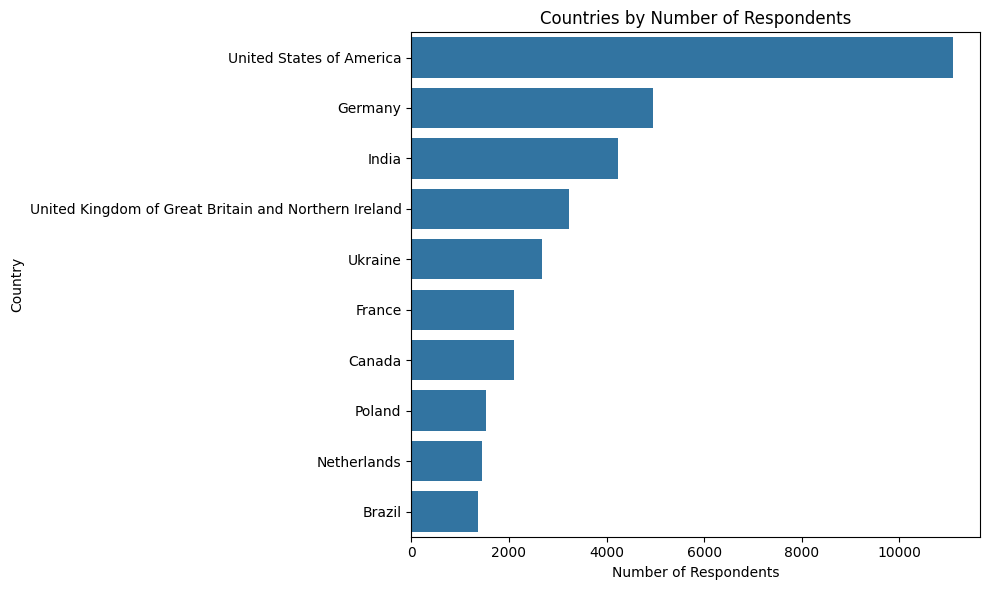

In [82]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)
plt.title('Countries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')
plt.tight_layout()

- USA account for a large share of respondents.

- Countries with strong tech communities (often the United States, India, Germany, UK, etc.) tend to dominate the survey.

- The distribution reflects where developer populations and survey reach are highest, not necessarily global workforce proportions.

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
